# Расследование II-06 · Экзамен для «Компаса»

**Бюро аналитических расследований, 16–17 апреля 2026 года.** Закупочная комиссия ждёт финальный ответ. Поставщик показывает почти идеальную оценку распознавания цифр, но в таблице появились `source_id`, варианты снимков и ранее не раскрытая партия C.

Ваша задача — проверить не только строки, но и единицу независимости. Связанные снимки одного источника не должны пересекать обучающую и тестовую выборки. После выбора процедуры вы один раз откроете партию C, оцените сдвиг, построите бутстреп-интервал с пересэмплированием источников и подготовите карточку модели и закупочную записку.

**Важно:** набор этого расследования — документированная **учебная синтетическая стресс-проверка**. Все изменения изображений искусственны; они не описывают реальный сканер или реального поставщика.

Ориентир времени — 6–8 часов.


## Маршрут финального аудита

1. Проверить происхождение, схему, типы, диапазоны, пропуски, дубликаты, целевой столбец и группы.
2. Воспроизвести построчное разбиение поставщика замороженной моделью II-05.
3. Проверить пересечение `source_id` и зафиксировать единицу независимости.
4. На одних и тех же фолдах `StratifiedGroupKFold` сравнить `DummyClassifier` и замороженную модель.
5. После фиксации процедуры открыть партию C ровно один раз.
6. Рассчитать macro-F1, ошибки по классам и бутстреп-интервал по источникам.
7. Выпустить карточку модели и закупочную записку с конкретными числами и ограничениями.

Практическая единица прогноза — одна строка изображения 8×8, но единица независимости — исходник `source_id`: его варианты должны оставаться вместе. Целевой столбец `digit` содержит классы 0–9. Решение о закупке требует качества на новых источниках и новой партии, поэтому построчная оценка поставщика сама по себе не является приёмочным тестом.

In [1]:
from __future__ import annotations

import hashlib
import random
import urllib.request
import zipfile
from pathlib import Path

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
NOTEBOOK_VARIANT = "learner"
CASE_SLUG = "case-06"
ARCHIVE_NAME = "part-2-case-06.zip"
COURSE_SITE = "https://mkuziuk.github.io/python-tutorial"
IN_COLAB = False

# При локальном запуске используем файлы из каталога расследования; в Colab скачиваем архив и проверяем его SHA-256.
# Импорт google.colab проходит только в Colab; локально возникает ImportError, и IN_COLAB остаётся False.
try:
    import google.colab  # type: ignore[import-not-found]  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def find_local_case() -> Path | None:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (
            (candidate / "README.md").is_file()
            and (candidate / f"{CASE_SLUG}.ipynb").is_file()
        ):
            return candidate
        nested = candidate / "projects" / "part-2" / CASE_SLUG
        if (nested / "README.md").exists():
            return nested
    return None

def download_colab_case() -> Path:
    destination = Path("/content") / f"python-tutorial-{CASE_SLUG}"
    destination.mkdir(parents=True, exist_ok=True)
    archive_path = destination / ARCHIVE_NAME
    archive_url = f"{COURSE_SITE}/downloads/{ARCHIVE_NAME}"
    checksum_url = f"{archive_url}.sha256"

    urllib.request.urlretrieve(archive_url, archive_path)
    # Сравниваем SHA-256 архива с опубликованной контрольной суммой перед распаковкой.
    with urllib.request.urlopen(checksum_url) as response:
        expected = response.read().decode("utf-8").split()[0].lower()
    actual = sha256_file(archive_path)
    if actual != expected:
        raise RuntimeError(f"SHA-256 архива не совпал: {actual} != {expected}")

    unpacked = destination / "unpacked"
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(unpacked)
    matches = sorted(unpacked.rglob(f"{CASE_SLUG}.ipynb"))
    if not matches:
        raise FileNotFoundError(f"В архиве нет {CASE_SLUG}.ipynb")
    return matches[0].parent

# DATA_DIR и ARTIFACTS_DIR строятся от найденного каталога расследования, поэтому текущая папка не влияет на пути.
CASE_DIR = find_local_case()
if CASE_DIR is None and IN_COLAB:
    CASE_DIR = download_colab_case()
if CASE_DIR is None:
    raise FileNotFoundError(
        f"Не найден каталог {CASE_SLUG}. Запустите тетрадь из каталога расследования."
    )

DATA_DIR = CASE_DIR / "data"
ARTIFACTS_DIR = CASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
print(f"Среда: {'Colab' if IN_COLAB else 'local'} | расследование: {CASE_DIR}")
print(f"RANDOM_STATE = {RANDOM_STATE}")


Среда: local | расследование: /private/var/folders/fv/ts0wlkms131g6wghvr6zgnpm0000gn/T/python-tutorial-part2-run-y2wh8jce/case-06
RANDOM_STATE = 42


In [2]:
import json
import warnings
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 90)
sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

def display_figure(fig):
    """Сохранить график в output даже при неинтерактивном backend."""
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


## 1. Вскрываем только карточку данных

`SOURCE.md` описывает генератор. Базовые изображения взяты из встроенного Digits. Для A/B к каждому исходнику добавлен стабильный случайный «отпечаток источника» и слабый шум; четыре близких варианта распределены между обучающей и тестовой выборками поставщика. Партия C содержит другие исходники и дополнительное синтетическое горизонтальное размазывание (smear) с сильным шумом.

Это намеренно сконструированный учебный пример утечки и сдвига распределения. Поля `instructional_synthetic` и `synthetic_transform` запрещают принять его за естественные измерения.


In [3]:
checksum_fields = (DATA_DIR / "CHECKSUMS.sha256").read_text(encoding="utf-8").split()
expected_sha256, checked_filename = checksum_fields
capture_path = DATA_DIR / "digits_compass.csv.gz"
assert checked_filename == capture_path.name
assert sha256_file(capture_path) == expected_sha256, "Derivative изменён"

# Первый проход читает только служебную границу партии, без меток и пикселей C.
batch_boundary = pd.read_csv(capture_path, usecols=["scanner_batch"])
c_file_rows = [position + 1 for position, batch in enumerate(batch_boundary["scanner_batch"]) if batch == "C"]
development_file_rows = [position + 1 for position, batch in enumerate(batch_boundary["scanner_batch"]) if batch != "C"]
development = pd.read_csv(capture_path, skiprows=c_file_rows)
pixel_columns = [f"pixel_{row}_{column}" for row in range(8) for column in range(8)]
required_metadata = {
    "sample_id", "source_id", "variant_id", "scanner_batch",
    "vendor_split", "digit", "instructional_synthetic", "synthetic_transform",
}
assert required_metadata.issubset(development.columns)
assert development["scanner_batch"].isin(["A", "B"]).all()
assert development["vendor_split"].isin(["train", "test"]).all()

# source_audit собирает проверяемые границы файла до моделирования.
source_audit = pd.Series({
    "rows": len(development),
    "columns": development.shape[1],
    "pixel_columns": len(pixel_columns),
    "sources": development["source_id"].nunique(),
    "missing_cells": int(development.isna().sum().sum()),
    "duplicate_rows": int(development.duplicated().sum()),
    "duplicate_sample_id": int(development["sample_id"].duplicated().sum()),
    "target_min": int(development["digit"].min()),
    "target_max": int(development["digit"].max()),
    "pixel_min": float(development[pixel_columns].min().min()),
    "pixel_max": float(development[pixel_columns].max().max()),
})
display(source_audit.to_frame("value"))

# Отдельные таблицы показывают типы и распределения, которые одна сводка скрыла бы.
display(development.dtypes.astype(str).value_counts().rename_axis("dtype").to_frame("columns"))
display(pd.crosstab(development["scanner_batch"], development["vendor_split"], margins=True))
display(development["digit"].value_counts().sort_index().rename("rows").to_frame())
display(development.groupby("scanner_batch")["source_id"].nunique().rename("sources").to_frame())

assert development["sample_id"].is_unique
assert development["instructional_synthetic"].eq(True).all()
assert development["digit"].between(0, 9).all()
assert development[pixel_columns].apply(lambda column: pd.api.types.is_numeric_dtype(column)).all()
assert development[pixel_columns].ge(0).all().all() and development[pixel_columns].le(16).all().all()
assert source_audit[["missing_cells", "duplicate_rows", "duplicate_sample_id"]].eq(0).all()

,value
rows,5388.0
columns,72.0
pixel_columns,64.0
sources,1347.0
missing_cells,0.0
duplicate_rows,0.0
duplicate_sample_id,0.0
target_min,0.0
target_max,9.0
pixel_min,0.0


,columns
dtype,
float64,64
str,6
int64,1
bool,1


vendor_split,test,train,All
scanner_batch,,,
A,1347,1347,2694
B,1347,1347,2694
All,2694,2694,5388


,rows
digit,
0,532
1,544
2,532
3,548
4,544
5,544
6,544
7,536
8,524


,sources
scanner_batch,
A,1347
B,1347


### Что подтвердил аудит источника

До фиксации решения прочитаны только 5 388 строк разработки A/B: 64 числовых пиксельных признака и служебные поля; целевая переменная принимает только значения 0–9. Пропусков, полных дубликатов и повторов `sample_id` нет, пиксели лежат в диапазоне 0–16. Эти строки соответствуют 1 347 исходникам: уникальность строки не означает независимость наблюдения.

Распределения классов и `source_id` относятся только к A/B. Строки C ещё не прочитаны, поэтому их метки, пиксели и статистики не могли повлиять на решение. Мы получили пригодную для анализа схему разработки; прежде чем считать метрику, визуально проверим восстановление изображений только на A/B.

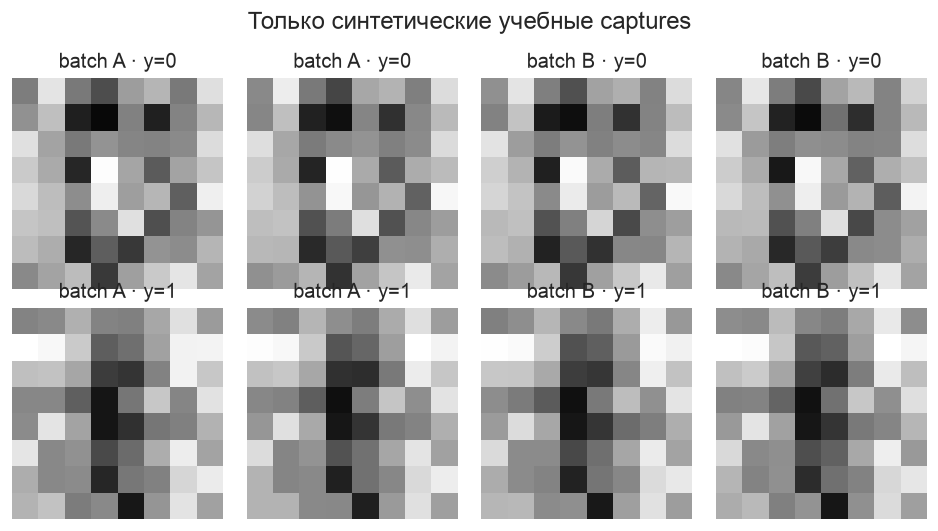

In [4]:
gallery_rows = development.groupby("scanner_batch", sort=True).head(4)
fig, axes = plt.subplots(2, 4, figsize=(8, 4.5))
for ax, (_, row) in zip(axes.ravel(), gallery_rows.iterrows(), strict=True):
    ax.imshow(row[pixel_columns].to_numpy(dtype=float).reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"batch {row['scanner_batch']} · y={row['digit']}")
    ax.axis("off")
fig.suptitle("Только синтетические учебные captures")
plt.tight_layout()
display_figure(fig)


### Что видно на примерах

Галерея показывает по четыре первые строки A и B и подтверждает, что пиксели правильно восстановлены в матрицы 8×8. Она не измеряет качество и ничего не сообщает о C: внешняя партия ещё не прочитана. Теперь можно воспроизвести оценку поставщика и проверить независимость её строк.

## 2. Воспроизводим заявленную границу

Модель уже заморожена в II-05: `StandardScaler → RBF SVC(C=2, gamma='scale')`. Мы не подбираем её по этому датасету. Сначала честно воспроизводим то, что названо тестовой выборкой поставщика, а затем проверяем, независимы ли его строки.


In [5]:
def locked_model():
    # Каждый вызов возвращает новый Pipeline замороженной конфигурации II-05.
    return make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=2, gamma="scale"),
    )

# development уже содержит только A/B; строки C всё ещё не прочитаны.
vendor_train_mask = development["vendor_split"].eq("train").to_numpy()
vendor_test_mask = development["vendor_split"].eq("test").to_numpy()
X_development = development[pixel_columns].to_numpy(dtype=float)
y_development = development["digit"].to_numpy()
source_groups = development["source_id"].to_numpy()
print(
    f"A/B: X={X_development.shape}, y={y_development.shape}, "
    f"source_id={source_groups.shape}; C ещё не прочитана"
)

A/B: X=(5388, 64), y=(5388,), source_id=(5388,); C ещё не прочитана


`X_development` имеет форму «строки A/B × 64 пикселя», а `y_development` и `source_groups` — по одному значению на строку. `batch_c` пока только отделена: её признаки и ответы ещё не переданы модели. Новый экземпляр `Pipeline` создаётся для каждого обучения, поэтому масштабирование оценивается только по обучающей части.

In [6]:
# Воспроизводим процедуру поставщика без изменения модели и границы.
vendor_model = locked_model()
vendor_model.fit(X_development[vendor_train_mask], y_development[vendor_train_mask])
vendor_predictions = vendor_model.predict(X_development[vendor_test_mask])
vendor_macro_f1 = f1_score(
    y_development[vendor_test_mask], vendor_predictions,
    labels=np.arange(10), average="macro", zero_division=0,
)
print(f"Vendor row-split macro-F1: {vendor_macro_f1:.3f}")

Vendor row-split macro-F1: 1.000


Macro-F1 — среднее F1 десяти классов с одинаковым весом каждого класса; F1 объединяет precision и recall. Поэтому показатель не позволяет многочисленным цифрам скрыть провал редкого класса. Построчная процедура даёт почти идеальное значение, но это число можно интерпретировать как качество на новых источниках только после проверки `source_id`.

### Упражнение: строки независимы или только уникальны?

`sample_id` уникален — но этого недостаточно. Сравните множества `source_id` в обучающую и тестовую выборки поставщика и посмотрите варианты нескольких пересекающихся источников. Если один оригинал породил строки с обеих сторон, такая тестовая выборка показывает, насколько модель узнаёт близкий снимок знакомого источника.


In [7]:
# source_id объединяет варианты одного исходного изображения.
vendor_train_sources = set(development.loc[vendor_train_mask, "source_id"])
vendor_test_sources = set(development.loc[vendor_test_mask, "source_id"])
leaked_sources = vendor_train_sources & vendor_test_sources
print(
    f"Источников train={len(vendor_train_sources)}, test={len(vendor_test_sources)}, "
    f"пересечение={len(leaked_sources)}"
)
display(
    development[development["source_id"].isin(sorted(leaked_sources)[:3])][
        ["sample_id", "source_id", "variant_id", "scanner_batch", "vendor_split"]
    ].sort_values(["source_id", "vendor_split"])
)

Источников train=1347, test=1347, пересечение=1347


,sample_id,source_id,variant_id,scanner_batch,vendor_split
0,digits-0000-a-test,digits-0000,a-test,A,test
2,digits-0000-b-test,digits-0000,b-test,B,test
1,digits-0000-a-train,digits-0000,a-train,A,train
3,digits-0000-b-train,digits-0000,b-train,B,train
4,digits-0001-a-test,digits-0001,a-test,A,test
6,digits-0001-b-test,digits-0001,b-test,B,test
5,digits-0001-a-train,digits-0001,a-train,A,train
7,digits-0001-b-train,digits-0001,b-train,B,train
8,digits-0002-a-test,digits-0002,a-test,A,test
10,digits-0002-b-test,digits-0002,b-test,B,test


Пересечение охватывает все источники A/B: у каждого исходника есть близкие варианты и в train, и в test. Следовательно, значение 1,000 отвечает узкому вопросу «узнает ли модель ещё один вариант уже знакомого исходника», а не закупочному вопросу о новых источниках. Для нужной границы все строки одного `source_id` должны переходить между фолдами вместе.

## 3. Групповая проверка

`StratifiedGroupKFold` одновременно старается сохранить классы и удерживает все варианты `source_id` в одной части выборки. У него нет магии: мы обязаны передать правильные `groups` и проверить непересечение.

**Упражнение:** получите OOF-прогнозы для всех A/B строк. Предобработка остаётся внутри конвейера.


In [8]:
grouped_cv = StratifiedGroupKFold(
    n_splits=3, shuffle=True, random_state=RANDOM_STATE
)
# Материализуем фолды один раз: baseline и кандидат получат буквально одинаковые индексы.
grouped_splits = list(
    grouped_cv.split(X_development, y_development, groups=source_groups)
)
fold_audit = []
for fold_number, (train_positions, validation_positions) in enumerate(grouped_splits, start=1):
    overlap = set(source_groups[train_positions]) & set(source_groups[validation_positions])
    fold_audit.append({
        "fold": fold_number,
        "train_rows": len(train_positions),
        "validation_rows": len(validation_positions),
        "train_sources": np.unique(source_groups[train_positions]).size,
        "validation_sources": np.unique(source_groups[validation_positions]).size,
        "source_overlap": len(overlap),
    })
fold_audit = pd.DataFrame(fold_audit)
display(fold_audit)
assert fold_audit["source_overlap"].eq(0).all()

,fold,train_rows,validation_rows,train_sources,validation_sources,source_overlap
0,1,3592,1796,898,449,0
1,2,3592,1796,898,449,0
2,3,3592,1796,898,449,0


Во всех трёх фолдах пересечение равно нулю: ни один вариант исходника не служит одновременно обучающим и проверочным примером. Число строк и источников по фолдам близко, но не обязано совпадать — алгоритм одновременно удерживает группы целиком и старается сохранить классы. Эта проверенная граница теперь подходит для честного сравнения простого ориентира и замороженной модели.

In [9]:
# Most-frequent baseline показывает качество правила без использования пикселей.
baseline_predictions = cross_val_predict(
    DummyClassifier(strategy="most_frequent"),
    X_development,
    y_development,
    groups=source_groups,
    cv=grouped_splits,
    n_jobs=1,
)
# Pipeline-кандидат использует те же train/validation индексы, что и baseline.
grouped_predictions = cross_val_predict(
    locked_model(),
    X_development,
    y_development,
    groups=source_groups,
    cv=grouped_splits,
    n_jobs=1,
)
baseline_macro_f1 = f1_score(
    y_development, baseline_predictions,
    labels=np.arange(10), average="macro", zero_division=0,
)
grouped_macro_f1 = f1_score(
    y_development, grouped_predictions,
    labels=np.arange(10), average="macro", zero_division=0,
)
grouped_comparison = pd.DataFrame({
    "model": ["DummyClassifier(most_frequent)", "StandardScaler → RBF SVC"],
    "macro_f1": [baseline_macro_f1, grouped_macro_f1],
    "same_grouped_splits": [True, True],
}).set_index("model")
display(grouped_comparison.round(3))

,macro_f1,same_grouped_splits
model,,
DummyClassifier(most_frequent),0.033,True
StandardScaler → RBF SVC,0.888,True


Baseline почти не решает десятиклассовую задачу: он всегда выбирает самый частый класс. Замороженный SVC значительно превосходит этот ориентир, поэтому пиксели несут полезную информацию, но его grouped OOF macro-F1 около 0,888 заметно ниже 1,000 поставщика. Разрыв примерно 0,112 — наблюдаемая часть демонстрационного качества, исчезающая при переносе на новые `source_id` внутри A/B.

In [10]:
grouped_recall = pd.Series(
    recall_score(
        y_development, grouped_predictions,
        labels=np.arange(10), average=None, zero_division=0,
    ),
    index=np.arange(10),
    name="grouped_recall",
)
display(grouped_recall.sort_values().to_frame().round(3))

,grouped_recall
8,0.781
9,0.806
3,0.828
5,0.886
2,0.887
1,0.897
4,0.915
7,0.946
6,0.961
0,0.974


Recall класса — доля объектов этого класса, найденных моделью. Сортировка показывает, какие цифры хуже переносятся на новые исходники A/B; таблица нужна как диагностический срез, а не как повод подбирать модель по партии C. Процедура и кандидат теперь зафиксированы, поэтому можно выполнить единственное вскрытие C.

## 4. Модель выбрана — открываем партию C

Только теперь обучаем замороженную модель на всех A/B и один раз строим прогноз для партии C. Источники C не встречались в A/B. Сдвиг распределения документирован генератором; он не обнаружен постфактум ради драматического результата.


In [11]:
# Решение заморожено: теперь единственный раз читаем оставшиеся строки файла — sealed C.
decision_locked = True
batch_c = pd.read_csv(capture_path, skiprows=development_file_rows)
assert decision_locked
assert batch_c["scanner_batch"].eq("C").all()
assert batch_c["vendor_split"].eq("holdout").all()
assert set(development["source_id"]).isdisjoint(batch_c["source_id"])
final_model = locked_model().fit(X_development, y_development)
X_batch_c = batch_c[pixel_columns].to_numpy(dtype=float)
y_batch_c = batch_c["digit"].to_numpy()
batch_c_predictions = final_model.predict(X_batch_c)
batch_c_macro_f1 = f1_score(
    y_batch_c, batch_c_predictions,
    labels=np.arange(10), average="macro", zero_division=0,
)

metric_comparison = pd.DataFrame({
    "evaluation": [
        "vendor row split", "source-grouped baseline",
        "source-grouped candidate", "sealed batch C",
    ],
    "macro_f1": [
        vendor_macro_f1, baseline_macro_f1,
        grouped_macro_f1, batch_c_macro_f1,
    ],
}).set_index("evaluation")
display(metric_comparison.round(3))

,macro_f1
evaluation,
vendor row split,1.000
source-grouped baseline,0.033
source-grouped candidate,0.888
sealed batch C,0.647


После фиксации процедуры C прочитана один раз и дала macro-F1 около 0,647. Теперь допустимы описательные срезы тех же финальных прогнозов, но не изменение модели или решения. Три оценки отвечают на разные вопросы: 1,000 относится к близким вариантам знакомых источников, около 0,888 — к новым источникам A/B, а около 0,647 — к новым источникам с дополнительным синтетическим сдвигом C. Разрывы равны примерно 0,112 и 0,241.

,precision,recall,f1-score,support
0,0.920,0.511,0.657,45.0
1,0.446,0.804,0.574,46.0
2,0.735,0.818,0.774,44.0
3,0.698,0.652,0.674,46.0
4,0.756,0.756,0.756,45.0
5,0.793,0.500,0.613,46.0
6,0.867,0.578,0.693,45.0
7,0.569,0.822,0.673,45.0
8,0.812,0.302,0.441,43.0
9,0.523,0.756,0.618,45.0


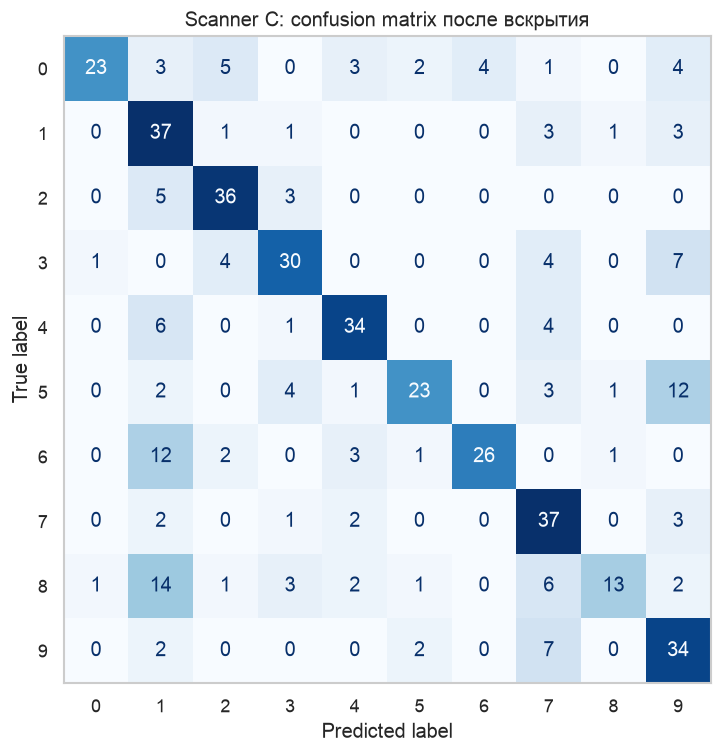

In [12]:
c_report = pd.DataFrame(
    classification_report(
        y_batch_c, batch_c_predictions, labels=np.arange(10),
        output_dict=True, zero_division=0,
    )
).T
display(c_report.loc[[str(i) for i in range(10)], ["precision", "recall", "f1-score", "support"]].round(3))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_batch_c, batch_c_predictions, labels=np.arange(10), cmap="Blues", ax=ax,
    colorbar=False,
)
ax.set_title("Scanner C: confusion matrix после вскрытия")
ax.grid(False)
display_figure(fig)


Таблица по классам отделяет типы ошибок: precision отвечает, какая доля предсказаний класса верна, recall — какая доля истинного класса найдена, F1 объединяет оба показателя, support показывает число примеров. Матрица указывает конкретные направления путаницы, поэтому ниже мы извлечём самые слабые классы и частые пары программно — без выбора удобных примеров вручную.

In [13]:
c_labels = np.arange(10)
c_confusion = pd.crosstab(
    pd.Series(y_batch_c, name="true"),
    pd.Series(batch_c_predictions, name="predicted"),
).reindex(index=c_labels, columns=c_labels, fill_value=0)
# mask() создаёт новую таблицу и не пытается изменять read-only массив pandas.
diagonal_mask = np.eye(len(c_labels), dtype=bool)
off_diagonal = c_confusion.mask(diagonal_mask, 0)
confusion_pairs = (
    off_diagonal.stack()
    .rename("errors")
    .loc[lambda values: values > 0]
    .sort_values(ascending=False)
    .head(5)
)
weakest_c_classes = (
    c_report.loc[[str(i) for i in c_labels], "recall"]
    .astype(float)
    .sort_values()
    .head(3)
)
display(weakest_c_classes.rename("recall").to_frame().round(3))
display(confusion_pairs.to_frame())

,recall
8,0.302
5,0.500
0,0.511


,,errors
true,predicted,
8,1,14
6,1,12
5,9,12
3,9,7
9,7,7


Слабейшие классы C и самые частые направленные пары ошибок называют, где именно сдвиг причиняет ущерб. Это наблюдение ограничено синтетической партией: оно поддерживает требование отдельных срезов на реальных данных, но не доказывает, что реальный сканер повторит те же путаницы.

### Упражнение: бутстреп-интервал с пересэмплированием источников

Ресемплируйте `source_id`, а не отдельные строки. Для каждой бутстреп-выборки включите все строки выбранного источника и пересчитайте macro-F1 с фиксированными метками классов 0–9. Здесь у C один снимок на источник, но функция остаётся корректной и при нескольких вариантах.

Интервал отражает вариативность этой конечной выборки источников; он не исправляет систематический сдвиг распределения и не является гарантией будущего качества.


In [14]:
# Пересэмплируем источники целиком, чтобы связанные строки оставались вместе.
def source_bootstrap_interval(
    y_true, y_pred, groups, *, repeats=1_000, confidence=0.95, random_state=42
):
    unique_groups = np.unique(groups)
    positions_by_group = {
        group: np.flatnonzero(groups == group) for group in unique_groups
    }
    rng = np.random.default_rng(random_state)
    scores = np.empty(repeats)
    for repeat in range(repeats):
        # replace=True выбирает источники с возвращением: один source_id может попасть в повтор несколько раз.
        sampled_groups = rng.choice(unique_groups, size=len(unique_groups), replace=True)
        sampled_positions = np.concatenate(
            [positions_by_group[group] for group in sampled_groups]
        )
        scores[repeat] = f1_score(
            y_true[sampled_positions], y_pred[sampled_positions],
            labels=np.arange(10), average="macro", zero_division=0,
        )
    alpha = 1.0 - confidence
    # При confidence=0.95 quantile берёт границы центральных 95% значений macro-F1.
    return tuple(np.quantile(scores, [alpha / 2, 1 - alpha / 2]))

batch_c_interval = source_bootstrap_interval(
    y_batch_c,
    batch_c_predictions,
    batch_c["source_id"].to_numpy(),
    random_state=RANDOM_STATE,
)
print(f"Scanner C macro-F1 95% source bootstrap CI: {batch_c_interval[0]:.3f}–{batch_c_interval[1]:.3f}")


Scanner C macro-F1 95% source bootstrap CI: 0.601–0.690


Полученный 95%-й интервал показывает разброс macro-F1 при повторном наборе источников из наблюдаемой C. Он охватывает точечную оценку и остаётся далеко ниже построчных 1,000. Интервал отражает конечный размер синтетической партии, но не учитывает неизвестные будущие типы сдвига и не превращает стресс-тест в гарантию производственного качества.

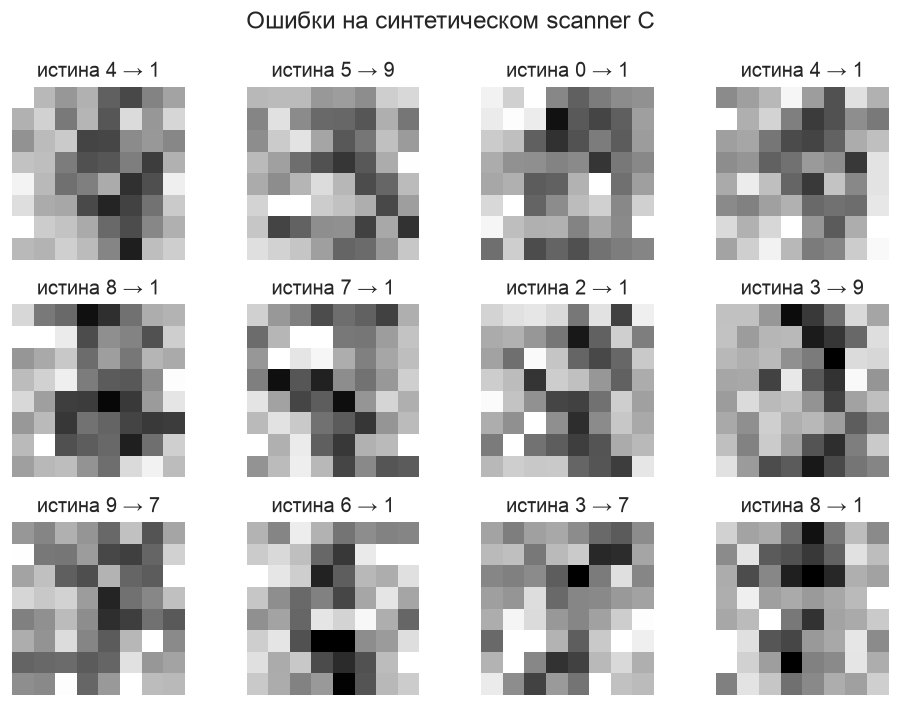

In [15]:
c_errors = np.flatnonzero(batch_c_predictions != y_batch_c)
shown = c_errors[:12]
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for ax in axes.ravel():
    ax.axis("off")
for ax, position in zip(axes.ravel(), shown, strict=False):
    ax.imshow(X_batch_c[position].reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"истина {y_batch_c[position]} → {batch_c_predictions[position]}")
    ax.axis("off")
fig.suptitle("Ошибки на синтетическом scanner C")
plt.tight_layout()
display_figure(fig)


Галерея показывает первые 12 ошибок в стабильном порядке строк, поэтому примеры воспроизводимы и не отобраны ради сильного впечатления. Размазывание часто сохраняет общую форму, но стирает различительные штрихи; это правдоподобное объяснение наблюдаемых путаниц, а не доказанная причина каждой ошибки.

## 5. Карточка модели и закупочная записка

Карточка модели должна назвать назначение, данные, модель, три оценки, ограничения и запрещённые применения. Закупочная записка отделяет методологический дефект от персонального обвинения: подгонка процедуры делает заявленный результат непригодным для решения, но сама по себе не устанавливает умысел или мошенничество.


In [16]:
model_card = {
    "model": "StandardScaler → RBF SVC(C=2, gamma='scale')",
    "intended_use": "Учебная проверка распознавания 8×8 цифр при смене источников.",
    "data": "Документированная синтетическая производная Digits; не данные реальных сканеров.",
    "unit_of_independence": "source_id",
    "evaluation": {
        "vendor_row_split_macro_f1": float(vendor_macro_f1),
        "source_grouped_baseline_macro_f1": float(baseline_macro_f1),
        "source_grouped_candidate_macro_f1": float(grouped_macro_f1),
        "scanner_c_macro_f1": float(batch_c_macro_f1),
        "scanner_c_source_bootstrap_95pct": [float(x) for x in batch_c_interval],
    },
    "limitations": [
        "Разбиение поставщика пересекается по source_id и не оценивает новые источники.",
        "Партия C — искусственный стресс-тест, а не оценка реального устройства.",
        "Малые изображения 8×8 не представляют документы бюро.",
        "Интервал не учитывает неизвестные будущие типы сдвига.",
    ],
    "prohibited_uses": [
        "автоматическое решение о личности или авторстве",
        "закупка или внедрение без независимого теста на данных целевой задачи",
    ],
}
weakest_text = ", ".join(
    f"{label}: recall={value:.3f}" for label, value in weakest_c_classes.items()
)
pairs_text = ", ".join(
    f"{true}→{predicted}: {count}"
    for (true, predicted), count in confusion_pairs.head(3).items()
)
procurement = {
    "established_fact": (
        f"Все {len(leaked_sources)} источников A/B пересекают train и test поставщика. "
        f"Macro-F1 кандидата: vendor={vendor_macro_f1:.3f}, grouped={grouped_macro_f1:.3f} "
        f"(разрыв {vendor_macro_f1 - grouped_macro_f1:.3f}), sealed C={batch_c_macro_f1:.3f} "
        f"(ещё {grouped_macro_f1 - batch_c_macro_f1:.3f}). "
        f"Слабейшие классы C: {weakest_text}; частые пары: {pairs_text}. "
        f"95%-й source-bootstrap CI: {batch_c_interval[0]:.3f}–{batch_c_interval[1]:.3f}."
    ),
    "supported_interpretation": (
        "Построчная метрика в основном измеряет узнавание вариантов знакомых источников; "
        "дополнительный спад C показывает чувствительность замороженной модели к заданному сдвигу."
    ),
    "not_proven": (
        "Аудит не устанавливает умысел, мошенничество, качество реального продукта "
        "или повторение тех же ошибок на настоящих сканерах."
    ),
    "limitations": (
        "Стресс-тест синтетический, изображения малы, модель и выборка учебные; "
        "бутстреп описывает только наблюдаемую C и не покрывает неизвестные сдвиги."
    ),
    "recommended_action": (
        "Приостановить закупку. Вернуться к оценке после независимого набора целевой задачи, "
        "разделения по source_id, заранее запечатанной партии и согласованных порогов по классам."
    ),
}

card_lines = [
    "# Model card · Compass Digits audit", "",
    f"**Model:** {model_card['model']}", "",
    f"**Intended use:** {model_card['intended_use']}", "",
    f"**Data:** {model_card['data']}", "",
    f"**Unit of independence:** {model_card['unit_of_independence']}", "",
    "## Evaluation", "",
]
card_lines += [f"- {key}: {value}" for key, value in model_card["evaluation"].items()]
card_lines += ["", "## Limitations", ""] + [f"- {item}" for item in model_card["limitations"]]
card_lines += ["", "## Prohibited uses", ""] + [f"- {item}" for item in model_card["prohibited_uses"]]
(ARTIFACTS_DIR / "model_card.md").write_text("\n".join(card_lines) + "\n", encoding="utf-8")

memo_text = "# Закупочная записка II-06\n\n" + "\n\n".join(
    f"## {key}\n{value}" for key, value in procurement.items()
) + "\n"
(ARTIFACTS_DIR / "procurement_memo.md").write_text(memo_text, encoding="utf-8")
print(memo_text)

# Закупочная записка II-06

## established_fact
Все 1347 источников A/B пересекают train и test поставщика. Macro-F1 кандидата: vendor=1.000, grouped=0.888 (разрыв 0.112), sealed C=0.647 (ещё 0.240). Слабейшие классы C: 8: recall=0.302, 5: recall=0.500, 0: recall=0.511; частые пары: 8→1: 14, 6→1: 12, 5→9: 12. 95%-й source-bootstrap CI: 0.601–0.690.

## supported_interpretation
Построчная метрика в основном измеряет узнавание вариантов знакомых источников; дополнительный спад C показывает чувствительность замороженной модели к заданному сдвигу.

## not_proven
Аудит не устанавливает умысел, мошенничество, качество реального продукта или повторение тех же ошибок на настоящих сканерах.

## limitations
Стресс-тест синтетический, изображения малы, модель и выборка учебные; бутстреп описывает только наблюдаемую C и не покрывает неизвестные сдвиги.

## recommended_action
Приостановить закупку. Вернуться к оценке после независимого набора целевой задачи, разделения по source_id, заранее запечат

Артефакты фиксируют происхождение данных, `source_id` как единицу независимости, baseline и три оценки кандидата. Записка называет слабые классы и частые пары C, но отделяет наблюдения от интерпретации и прямо перечисляет недоказанные утверждения. Это делает решение проверяемым: комиссия может вернуться к нему только с независимыми реальными данными и заранее согласованными порогами.

In [17]:
if NOTEBOOK_VARIANT == "solution":
    vendor_gap = vendor_macro_f1 - grouped_macro_f1
    shift_gap = grouped_macro_f1 - batch_c_macro_f1
    assert len(leaked_sources) == development["source_id"].nunique()
    assert fold_audit["source_overlap"].eq(0).all()
    assert baseline_macro_f1 < grouped_macro_f1
    assert grouped_comparison["same_grouped_splits"].all()
    assert vendor_gap >= 0.05
    assert shift_gap >= 0.05
    assert 0.87 <= grouped_macro_f1 <= 0.91
    assert 0.61 <= batch_c_macro_f1 <= 0.69
    assert 0 <= batch_c_interval[0] <= batch_c_macro_f1 <= batch_c_interval[1] <= 1
    assert set(procurement) == {
        "established_fact", "supported_interpretation", "not_proven",
        "limitations", "recommended_action"
    }
    print(
        f"Проверки II-06 пройдены: vendor→group gap={vendor_gap:.3f}; "
        f"group→C gap={shift_gap:.3f}."
    )
else:
    print("Учебный вариант: строгие проверки включатся после сверки с решением.")


Проверки II-06 пройдены: vendor→group gap=0.112; group→C gap=0.240.


Автоматические проверки подтверждают нулевое пересечение групп в фолдах, ожидаемые два разрыва, корректное положение точечной оценки внутри интервала и полноту записки. Они проверяют учебный контракт, но не заменяют внешний аудит данных или продукта.

## Финал протокола «Компас»

Построчные 1,000 объясняются тем, что **все источники A/B** представлены близкими вариантами по обе стороны разбиения. При переносе на новые `source_id` macro-F1 снижается примерно до **0,888**: около **0,112** демонстрационного качества исчезает вместе с родством примеров. На запечатанной синтетической партии C оценка падает примерно до **0,647**, то есть ещё на **0,241**; конкретные слабые классы, пары ошибок и 95%-й интервал перечислены в созданной записке.

Закупку следует приостановить. Возврат к оценке возможен после независимого набора реальной целевой задачи, группировки по источникам, заранее запечатанной партии внедрения, достаточного числа объектов каждого класса и согласованных до вскрытия порогов. Синтетические данные не доказывают качество реального сканера, повторение тех же путаниц, личный умысел или мошенничество.

Выполните **Restart Kernel → Run All** и сверьте `check_result.md`.

**Типичная ошибка:** открыть C, увидеть спад и менять модель. Тогда C перестаёт быть изолированной проверкой; следующая оценка потребует новой независимой партии.

**Расширение:** до новой партии зафиксируйте минимальный macro-F1, минимальный recall каждого класса и допустимую ширину интервала, затем симулируйте решение комиссии без дополнительного подбора.